In [1]:
# ==============================
# 1. IMPORTS
# ==============================
import os, random
import torch
import timm
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from collections import Counter
import matplotlib.pyplot as plt

# ==============================
# 2. CONFIGURATION
# ==============================
SEED = 42
BATCH_SIZE = 64  # Increased since we have 2 GPUs (32 per GPU)
EPOCHS = 8
LR_BACKBONE = 1e-5
LR_HEAD     = 3e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENSEMBLE_WEIGHTS = {"swin": 0.6, "resnet": 0.4}

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed()

print(f"🚀 Initializing DrishtiAI on {torch.cuda.device_count()} GPU(s)...")

# ==============================
# 3. LOAD DATASET
# ==============================
print("📦 Downloading/Loading Hugging Face Dataset...")
ds = load_dataset("JamieWithofs/Deepfake-and-real-images-4")
train_ds = ds["train"]
val_ds   = ds["validation"] if "validation" in ds else ds["test"]
test_ds  = ds["test"] if "test" in ds else val_ds

# ==============================
# 4. TRANSFORMS & DATASET CLASS
# ==============================
train_tfms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet norm
])

val_tfms = T.Compose([
    T.Resize((224, 224)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class HFDataset(Dataset):
    def __init__(self, hf_ds, transform):
        self.ds = hf_ds
        self.transform = transform
        
    def __len__(self):
        return len(self.ds)
        
    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["image"].convert("RGB")
        img = self.transform(img)
        label = int(item["label"])
        return img, label

train_dataset = HFDataset(train_ds, train_tfms)
val_dataset   = HFDataset(val_ds, val_tfms)
test_dataset  = HFDataset(test_ds, val_tfms)

# num_workers=4 is the sweet spot for Kaggle to avoid RAM crashes
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# ==============================
# 5. MODEL INITIALIZATION (Dual GPU)
# ==============================
swin_model   = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=2)
resnet_model = timm.create_model("resnet50", pretrained=True, num_classes=2)

# Wrap models for T4 x2
if torch.cuda.device_count() > 1:
    print("⚖️ Wrapping models in DataParallel for multi-GPU training...")
    swin_model = nn.DataParallel(swin_model)
    resnet_model = nn.DataParallel(resnet_model)

swin_model   = swin_model.to(DEVICE)
resnet_model = resnet_model.to(DEVICE)

# ==============================
# 6. CLASS WEIGHTS & OPTIMIZER
# ==============================
labels = [int(x["label"]) for x in train_ds]
counts = Counter(labels)
w0 = (counts[0]+counts[1]) / (2*counts[0])
w1 = (counts[0]+counts[1]) / (2*counts[1])
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def get_optimizer(model, lr_backbone=LR_BACKBONE, lr_head=LR_HEAD):
    backbone_params, head_params = [], []
    for name, p in model.named_parameters():
        if "head" in name or "fc" in name:
            head_params.append(p)
        else:
            backbone_params.append(p)
    return torch.optim.AdamW([
        {'params': backbone_params, 'lr': lr_backbone},
        {'params': head_params, 'lr': lr_head}
    ])

# ==============================
# 7. APPLY FREEZING FIX
# ==============================
# Note: 'module.' is added to names because of DataParallel
for name, p in swin_model.named_parameters():
    if "stage4" in name or "head" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False  # FIX: Correctly freezing earlier layers

for name, p in resnet_model.named_parameters():
    if "layer4" in name or "fc" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False  # FIX: Correctly freezing earlier layers

# ==============================
# 8. TRAINING ENGINE
# ==============================
scaler = torch.amp.GradScaler('cuda')

def train_one_model(model, model_name, loader, val_loader, epochs=EPOCHS):
    optimizer = get_optimizer(model)
    best_f1 = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                out = model(imgs)
                loss = criterion(out, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            
        # Validation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                preds = torch.argmax(out, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy()) # FIX: Move labels to CPU
                
        f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Loss={total_loss/len(loader):.4f} | Val F1={f1:.4f}")
        
        # FIX: Safe DataParallel Saving
        if f1 > best_f1:
            best_f1 = f1
            model_to_save = model.module if isinstance(model, nn.DataParallel) else model
            save_path = f"{model_name}_best.pth"
            torch.save(model_to_save.state_dict(), save_path)
            
    print(f"💾 Best {model_name} saved with F1: {best_f1:.4f}\n")
    
    # Reload best weights for ensemble
    model_to_load = model.module if isinstance(model, nn.DataParallel) else model
    model_to_load.load_state_dict(torch.load(f"{model_name}_best.pth"))
    return model

# ==============================
# 9. EXECUTE TRAINING
# ==============================
print("🔥 Phase 1: Training Swin Transformer...")
swin_model = train_one_model(swin_model, "Swin", train_loader, val_loader)

print("🔥 Phase 2: Training ResNet50...")
resnet_model = train_one_model(resnet_model, "ResNet", train_loader, val_loader)

# ==============================
# 10. ENSEMBLE PREDICTION & EVALUATION
# ==============================
def predict_ensemble(imgs, tta=True):
    imgs_orig = imgs.to(DEVICE)
    imgs_list = [imgs_orig]

    if tta:
        imgs_hf = torch.flip(imgs_orig, dims=[3])
        imgs_list.append(imgs_hf)

    total_probs = 0
    swin_model.eval()
    resnet_model.eval()
    
    for batch in imgs_list:
        with torch.no_grad():
            out_swin = torch.softmax(swin_model(batch), dim=1)
            out_res  = torch.softmax(resnet_model(batch), dim=1)
            total_probs += ENSEMBLE_WEIGHTS["swin"] * out_swin + ENSEMBLE_WEIGHTS["resnet"] * out_res

    total_probs /= len(imgs_list)
    preds = torch.argmax(total_probs, dim=1)
    return preds.cpu().numpy()

def evaluate_ensemble(loader, loader_name="Dataset", tta=True):
    print(f"\n📊 Evaluating Ensemble on {loader_name}...")
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        preds = predict_ensemble(imgs, tta=tta)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Ensemble Accuracy: {acc:.4f} | Ensemble F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=["FAKE", "REAL"]))

evaluate_ensemble(val_loader, "Validation Set")
evaluate_ensemble(test_loader, "Test Set")

# ==============================
# 11. INFERENCE SCRIPT (TEST YOUR OWN IMAGE)
# ==============================
def test_custom_image(image_path):
    """Test the trained ensemble on a local image file."""
    try:
        img = Image.open(image_path).convert("RGB")
        img_tensor = val_tfms(img).unsqueeze(0) # Add batch dimension
        
        pred = predict_ensemble(img_tensor, tta=True)[0]
        label = "REAL" if pred == 1 else "FAKE"
        
        plt.imshow(img)
        plt.title(f"DrishtiAI Prediction: {label}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error loading image: {e}")

# Example usage (Uncomment and put a valid path when ready)
# test_custom_image("/kaggle/input/your-dataset-here/test_face.jpg")

🚀 Initializing DrishtiAI on 2 GPU(s)...
📦 Downloading/Loading Hugging Face Dataset...


README.md:   0%|          | 0.00/622 [00:00<?, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/207M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/287M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/35304 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/53184 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

⚖️ Wrapping models in DataParallel for multi-GPU training...
🔥 Phase 1: Training Swin Transformer...
[Swin] Epoch 1/8 | Loss=0.5188 | Val F1=0.7485
[Swin] Epoch 2/8 | Loss=0.4675 | Val F1=0.7523
[Swin] Epoch 3/8 | Loss=0.4559 | Val F1=0.7641
[Swin] Epoch 4/8 | Loss=0.4515 | Val F1=0.7634
[Swin] Epoch 5/8 | Loss=0.4455 | Val F1=0.7657
[Swin] Epoch 6/8 | Loss=0.4437 | Val F1=0.7684
[Swin] Epoch 7/8 | Loss=0.4427 | Val F1=0.7655
[Swin] Epoch 8/8 | Loss=0.4404 | Val F1=0.7697
💾 Best Swin saved with F1: 0.7697

🔥 Phase 2: Training ResNet50...
[ResNet] Epoch 1/8 | Loss=0.5385 | Val F1=0.7556
[ResNet] Epoch 2/8 | Loss=0.4207 | Val F1=0.7993
[ResNet] Epoch 3/8 | Loss=0.3695 | Val F1=0.8229
[ResNet] Epoch 4/8 | Loss=0.3336 | Val F1=0.8411
[ResNet] Epoch 5/8 | Loss=0.3061 | Val F1=0.8451
[ResNet] Epoch 6/8 | Loss=0.2858 | Val F1=0.8613
[ResNet] Epoch 7/8 | Loss=0.2658 | Val F1=0.8676
[ResNet] Epoch 8/8 | Loss=0.2525 | Val F1=0.8705
💾 Best ResNet saved with F1: 0.8705


📊 Evaluating Ensemble on V

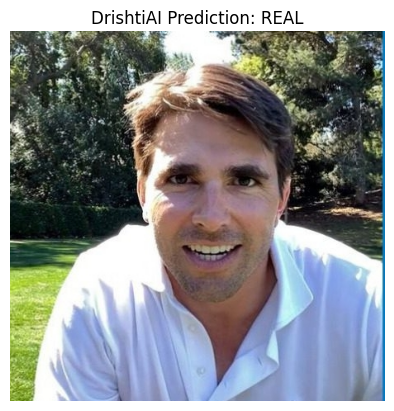

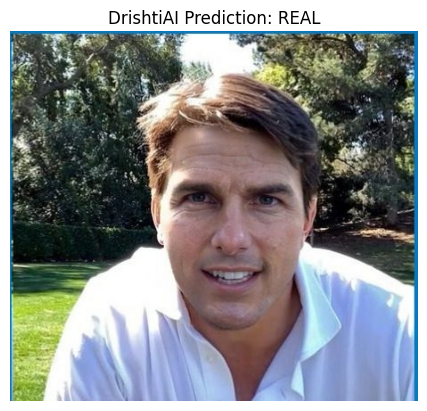

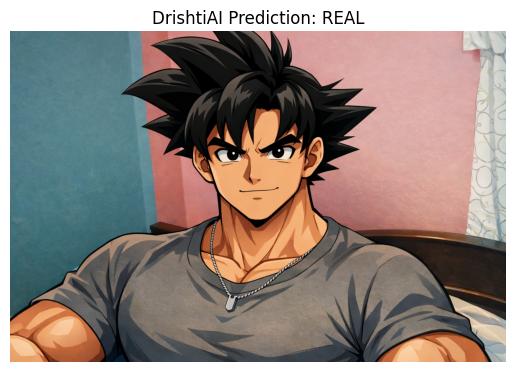

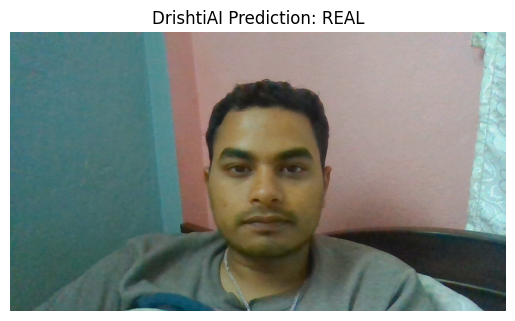

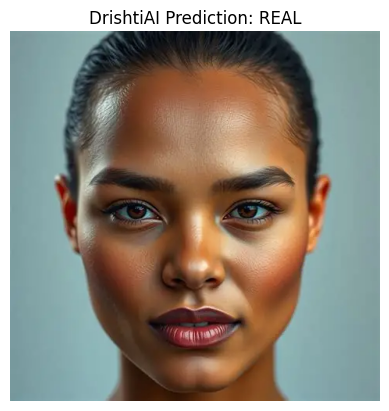

In [2]:
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/real.jpeg")
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/test.jpeg")
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/me.jpg")
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/me1.jpg")
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/fake.webp")

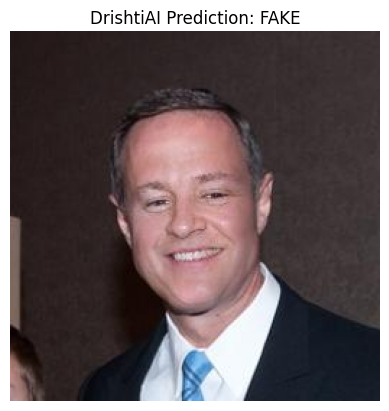

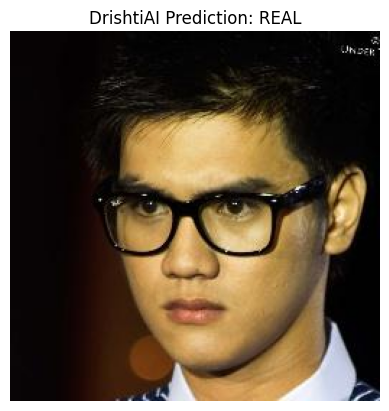

In [3]:
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/deepfake/f.jpg")
test_custom_image("/kaggle/input/datasets/sakshyamkarki04/deepfake/r.jpg")


In [12]:
# ==============================
# 1. IMPORTS & SETUP
# ==============================
import os, random
import kagglehub
import torch
import timm
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Configuration
SEED = 42
BATCH_SIZE = 64  # Dual GPU
EPOCHS = 5       # Fewer epochs needed for fine-tuning
LR_BACKBONE = 1e-6 # Much lower to prevent forgetting old knowledge
LR_HEAD     = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENSEMBLE_WEIGHTS = {"swin": 0.6, "resnet": 0.4}

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed()

print(f"🚀 Initializing Fine-Tuning Pipeline on {torch.cuda.device_count()} GPU(s)...")

# ==============================
# 2. DOWNLOAD & LOAD NEW DATASET
# ==============================
print("📦 Downloading 190k Dataset via KaggleHub...")
DATASET_PATH = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
print(f"Dataset stored at: {DATASET_PATH}")

DATASET_PATH = "/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset"

# ==============================
# 3. TRANSFORMS (With Robust Augmentation)
# ==============================
train_tfms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))], p=0.3),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tfms = T.Compose([
    T.Resize((224, 224)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Use ImageFolder for standard folder structures
train_dataset = datasets.ImageFolder(root=os.path.join(DATASET_PATH, 'Train'), transform=train_tfms)
val_dataset   = datasets.ImageFolder(root=os.path.join(DATASET_PATH, 'Validation'), transform=val_tfms)
test_dataset  = datasets.ImageFolder(root=os.path.join(DATASET_PATH, 'Test'), transform=val_tfms)

print(f"📂 Class mapping: {train_dataset.class_to_idx}") # Ensure 'Real' is 1

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# ==============================
# 4. INITIALIZE MODELS
# ==============================
swin_model   = timm.create_model("swin_tiny_patch4_window7_224", num_classes=2)
resnet_model = timm.create_model("resnet50", num_classes=2)

# ==============================
# 5. LOAD PREVIOUS WEIGHTS (TRANSFER LEARNING)
# ==============================
print("🧠 Loading previous DrishtiAI brains...")
# NOTE: Update these paths if your weights are saved in a specific Kaggle /input/ folder
swin_model.load_state_dict(torch.load("/kaggle/input/models/sakshyamkarki04/swin/pytorch/default/1/Swin_best (2).pth", map_location="cpu"))
resnet_model.load_state_dict(torch.load("/kaggle/input/models/sakshyamkarki04/resnet/pytorch/default/1/ResNet_best (2).pth", map_location="cpu"))

# Wrap in DataParallel AFTER loading weights to avoid 'module.' key errors
if torch.cuda.device_count() > 1:
    swin_model = nn.DataParallel(swin_model)
    resnet_model = nn.DataParallel(resnet_model)

swin_model   = swin_model.to(DEVICE)
resnet_model = resnet_model.to(DEVICE)

# ==============================
# 6. LOSS & OPTIMIZER
# ==============================
# We omit class weights here assuming the 190k dataset is mostly balanced
criterion = nn.CrossEntropyLoss()

def get_optimizer(model):
    backbone_params, head_params = [], []
    for name, p in model.named_parameters():
        if "head" in name or "fc" in name:
            head_params.append(p)
        else:
            backbone_params.append(p)
    return torch.optim.AdamW([
        {'params': backbone_params, 'lr': LR_BACKBONE},
        {'params': head_params, 'lr': LR_HEAD}
    ], weight_decay=1e-4)

# ==============================
# 7. FINE-TUNING ENGINE
# ==============================
scaler = torch.amp.GradScaler('cuda')

def train_one_model(model, model_name, loader, val_loader, epochs=EPOCHS):
    optimizer = get_optimizer(model)
    best_f1 = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                out = model(imgs)
                loss = criterion(out, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            
        # Validation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(DEVICE)
                out = model(imgs)
                preds = torch.argmax(out, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
                
        f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Loss={total_loss/len(loader):.4f} | Val F1={f1:.4f}")
        
        # Save Best Model
        if f1 > best_f1:
            best_f1 = f1
            model_to_save = model.module if isinstance(model, nn.DataParallel) else model
            torch.save(model_to_save.state_dict(), f"{model_name}_finetuned.pth")
            
    print(f"💾 Best {model_name} saved with F1: {best_f1:.4f}\n")
    
    # Reload best weights
    model_to_load = model.module if isinstance(model, nn.DataParallel) else model
    model_to_load.load_state_dict(torch.load(f"{model_name}_finetuned.pth"))
    return model

# ==============================
# 8. EXECUTE FINE-TUNING
# ==============================
print("🔥 Phase 1: Fine-Tuning Swin Transformer...")
swin_model = train_one_model(swin_model, "Swin", train_loader, val_loader)

print("🔥 Phase 2: Fine-Tuning ResNet50...")
resnet_model = train_one_model(resnet_model, "ResNet", train_loader, val_loader)

# ==============================
# 9. ENSEMBLE EVALUATION
# ==============================
def predict_ensemble(imgs, tta=True):
    imgs_orig = imgs.to(DEVICE)
    imgs_list = [imgs_orig]

    if tta:
        imgs_list.append(torch.flip(imgs_orig, dims=[3]))

    total_probs = 0
    swin_model.eval()
    resnet_model.eval()
    
    for batch in imgs_list:
        with torch.no_grad():
            out_swin = torch.softmax(swin_model(batch), dim=1)
            out_res  = torch.softmax(resnet_model(batch), dim=1)
            total_probs += ENSEMBLE_WEIGHTS["swin"] * out_swin + ENSEMBLE_WEIGHTS["resnet"] * out_res

    total_probs /= len(imgs_list)
    probs_real = total_probs[:, 1].cpu().numpy()
    preds = (probs_real >= 0.51).astype(int) # Using your calibrated threshold
    return preds, probs_real

def evaluate_ensemble(loader, loader_name="Dataset"):
    print(f"\n📊 Evaluating Ensemble on {loader_name}...")
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        preds, _ = predict_ensemble(imgs, tta=True)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Ensemble Accuracy: {acc:.4f} | Ensemble F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=["FAKE", "REAL"]))

evaluate_ensemble(val_loader, "Validation Set")
evaluate_ensemble(test_loader, "Test Set")

# ==============================
# 10. FINAL PREDICTION FUNCTION
# ==============================
def predict_custom_image(image_path, threshold=0.51):
    try:
        img_pil = Image.open(image_path).convert("RGB")
        img_tensor = val_tfms(img_pil).unsqueeze(0).to(DEVICE)
        
        preds, probs = predict_ensemble(img_tensor, tta=True)
        
        label = "REAL" if preds[0] == 1 else "FAKE"
        confidence = probs[0] if label == "REAL" else 1.0 - probs[0]
        
        plt.imshow(img_pil)
        color = 'green' if label == "REAL" else 'red'
        plt.title(f"DrishtiAI: {label} ({confidence*100:.2f}%)", color=color, fontweight='bold')
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error: {e}")



🚀 Initializing Fine-Tuning Pipeline on 2 GPU(s)...
📦 Downloading 190k Dataset via KaggleHub...
Dataset stored at: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images
📂 Class mapping: {'Fake': 0, 'Real': 1}
🧠 Loading previous DrishtiAI brains...
🔥 Phase 1: Fine-Tuning Swin Transformer...
[Swin] Epoch 1/5 | Loss=0.1420 | Val F1=0.9621
[Swin] Epoch 2/5 | Loss=0.0606 | Val F1=0.9738
[Swin] Epoch 3/5 | Loss=0.0461 | Val F1=0.9761
[Swin] Epoch 4/5 | Loss=0.0392 | Val F1=0.9818
[Swin] Epoch 5/5 | Loss=0.0330 | Val F1=0.9808
💾 Best Swin saved with F1: 0.9818

🔥 Phase 2: Fine-Tuning ResNet50...
[ResNet] Epoch 1/5 | Loss=0.3674 | Val F1=0.8293
[ResNet] Epoch 2/5 | Loss=0.2843 | Val F1=0.8584
[ResNet] Epoch 3/5 | Loss=0.2480 | Val F1=0.8748
[ResNet] Epoch 4/5 | Loss=0.2257 | Val F1=0.8774
[ResNet] Epoch 5/5 | Loss=0.2081 | Val F1=0.8869
💾 Best ResNet saved with F1: 0.8869


📊 Evaluating Ensemble on Validation Set...
Ensemble Accuracy: 0.9805 | Ensemble F1: 0.9805
              precision  

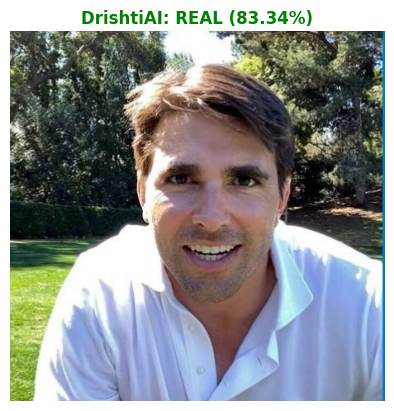

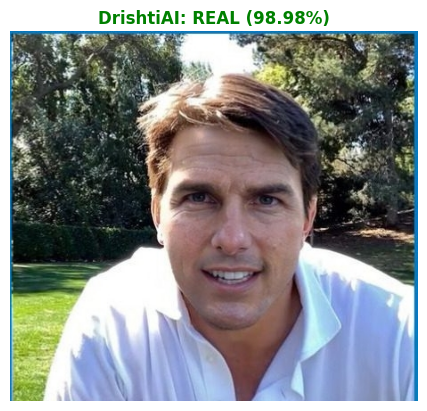

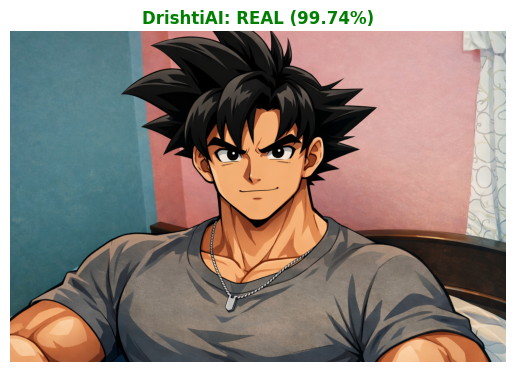

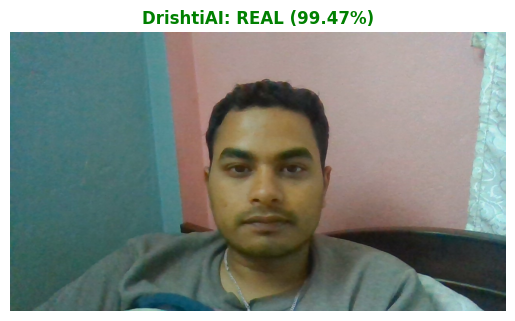

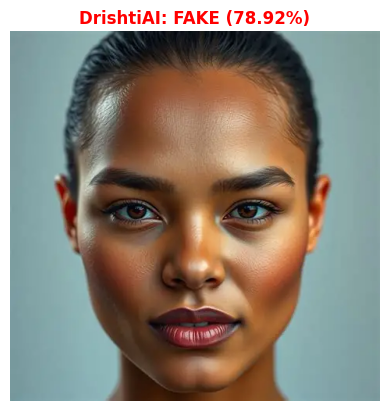

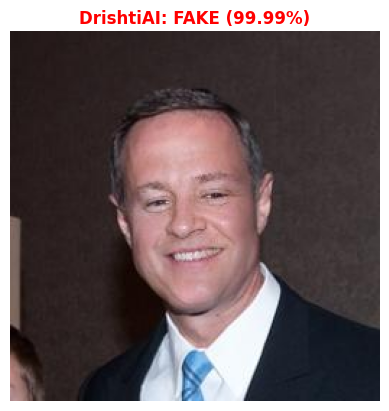

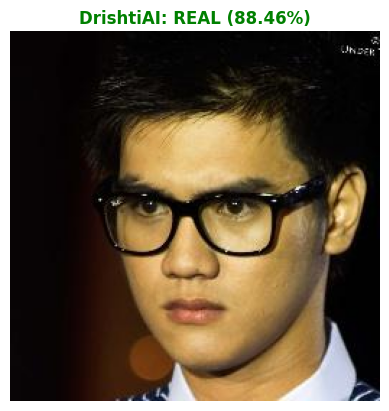

In [13]:
predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/real.jpeg")
predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/test.jpeg")
predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/me.jpg")
predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/me1.jpg")
predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/testing/fake.webp")

predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/deepfake/f.jpg")
predict_custom_image("/kaggle/input/datasets/sakshyamkarki04/deepfake/r.jpg")


In [2]:
pip install grad-cam timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.9 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0d6cfe1a3874019f47e7c34d23a2c70fdda73b8b48509a998d25dc6a1e3bc14f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Note: you may need to restart the kernel to use updated packages.


🧠 Initializing Swin Transformer...
🚀 Fine-tuning on DeepDetect-2025...


100%|██████████| 2826/2826 [19:00<00:00,  2.48it/s]


📊 Evaluating Metrics...


100%|██████████| 681/681 [05:01<00:00,  2.26it/s]


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Real       0.90      0.91      0.91     10399
        Fake       0.92      0.91      0.91     11377

    accuracy                           0.91     21776
   macro avg       0.91      0.91      0.91     21776
weighted avg       0.91      0.91      0.91     21776



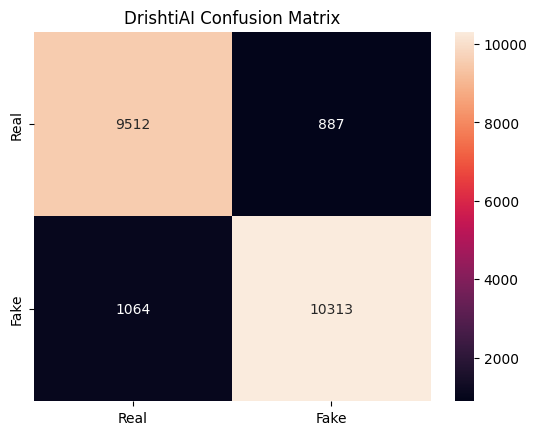

[ WARN:0@3923.032] global loadsave.cpp:275 findDecoder imread_('path_to_sample_image.jpg'): can't open/read file: check file path/integrity


TypeError: 'NoneType' object is not subscriptable

In [3]:
import torch
import torch.nn as nn
import timm
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Grad-CAM Imports
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

# ==============================
# 1. SETUP & CONFIGURATION
# ==============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 3
# Update these paths with your actual Kaggle input paths
TRAIN_DIR = "/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train"
TEST_DIR = "/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/test"
PREVIOUS_WEIGHTS = "/kaggle/input/models/sakshyamkarki04/swin1/pytorch/default/1/Swin_finetuned (1).pth"

# ==============================
# 2. DATA PREPARATION
# ==============================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# 3. MODEL LOADING & FINE-TUNING
# ==============================
def train_drishti():
    print("🧠 Initializing Swin Transformer...")
    model = timm.create_model("swin_tiny_patch4_window7_224", num_classes=2)
    
    # Load previous 190k weights
    model.load_state_dict(torch.load(PREVIOUS_WEIGHTS, map_location=DEVICE))
    model.to(DEVICE)

    # Differential Learning Rate: Head learns faster than backbone
    optimizer = torch.optim.AdamW([
        {'params': model.head.parameters(), 'lr': 1e-5},
        {'params': model.layers.parameters(), 'lr': 1e-7}
    ])
    criterion = nn.CrossEntropyLoss()

    print(f"🚀 Fine-tuning on DeepDetect-2025...")
    for epoch in range(EPOCHS):
        model.train()
        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    torch.save(model.state_dict(), "DrishtiAI_Final.pth")
    return model

# ==============================
# 4. COMPREHENSIVE TESTING
# ==============================
def run_test(model, loader):
    model.eval()
    y_true, y_pred = [], []
    
    print("📊 Evaluating Metrics...")
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title("DrishtiAI Confusion Matrix")
    plt.show()

# ==============================
# EXECUTION
# ==============================
model = train_drishti()
run_test(model, test_loader)


In [11]:

# ==============================
# 5. GRAD-CAM & PREDICTION
# ==============================
def reshape_transform(tensor, height=7, width=7):
    # For Swin Tiny, the final embedding dimension is 768.
    # The number of tokens should be 49 (7x7).
    # If the tensor is windowed (e.g., B*num_windows, window_size, C), 
    # we need to ensure it's in (B, 49, 768) before reshaping.
    
    # Check if the tensor is in (B, L, C) format
    if len(tensor.shape) == 3:
        # Most likely (1, 49, 768)
        result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    else:
        # If it's a windowed tensor, we take the mean or first part to get back to 49 tokens
        # This usually happens if targeting layers inside the window attention
        result = tensor[-1:].reshape(1, height, width, -1) 
        
    # Bring it to (Batch, Channels, Height, Width) for Grad-CAM
    result = result.transpose(2, 3).transpose(1, 2)
    return result

def predict_with_gradcam(model, img_path):
    model.eval()
    
    # Preprocess Image
    rgb_img = cv2.imread(img_path, 1)[:, :, ::-1]
    rgb_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))
    input_tensor = preprocess_image(np.float32(rgb_img) / 255., 
                                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).to(DEVICE)

    # Initialize Grad-CAM
    # Target Layer: Typically the last normalization layer in the last block
    target_layers = [model.layers[-1].blocks[-1].norm1]
    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

    # Generate CAM
    targets = [ClassifierOutputTarget(1)] # Focus on 'Fake' class
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(np.float32(rgb_img) / 255., grayscale_cam, use_rgb=True)

    # Prediction
    output = model(input_tensor)
    prob = torch.softmax(output, dim=1)[0]
    label = "FAKE" if prob[1] > 0.5 else "REAL"
    confidence = prob[1].item() if label == "FAKE" else prob[0].item()

    # Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"Original: {label} ({confidence:.2%})")
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM (Attention Areas)")
    plt.show()


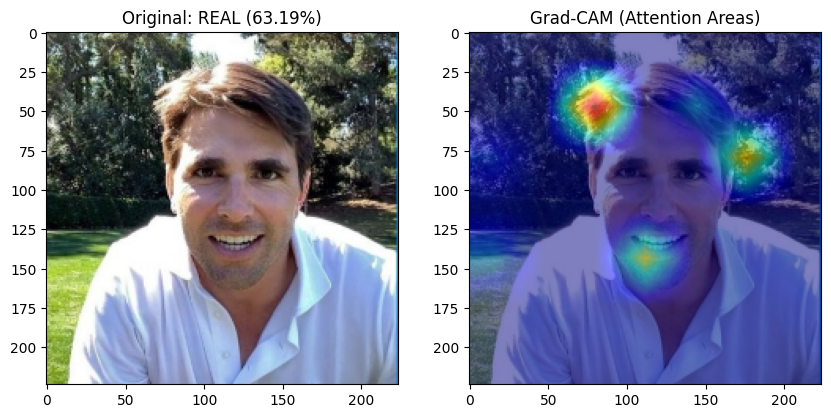

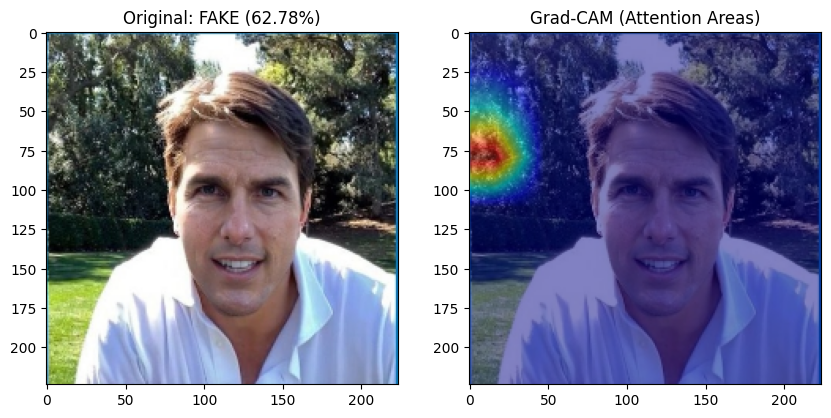

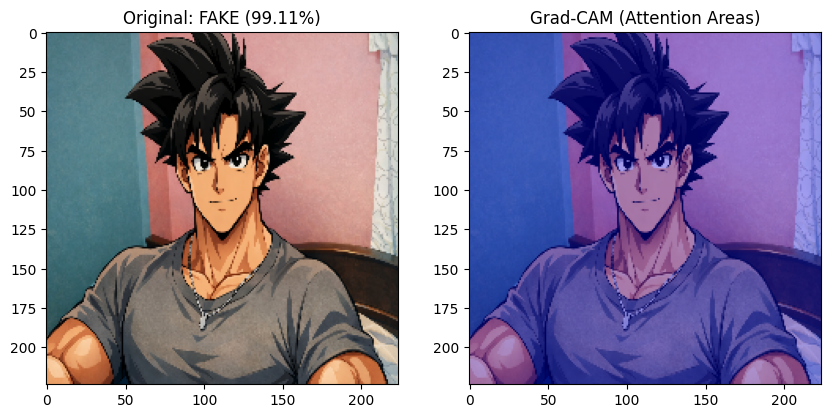

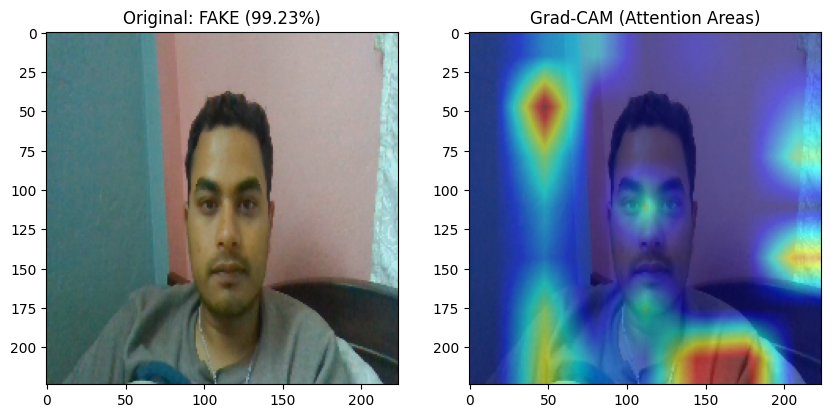

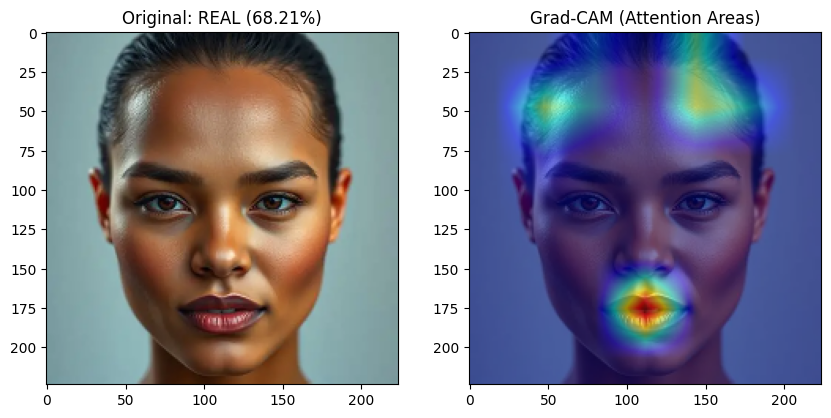

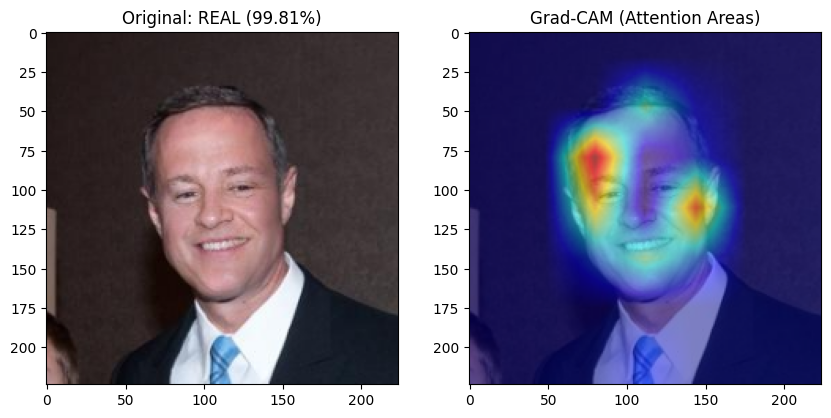

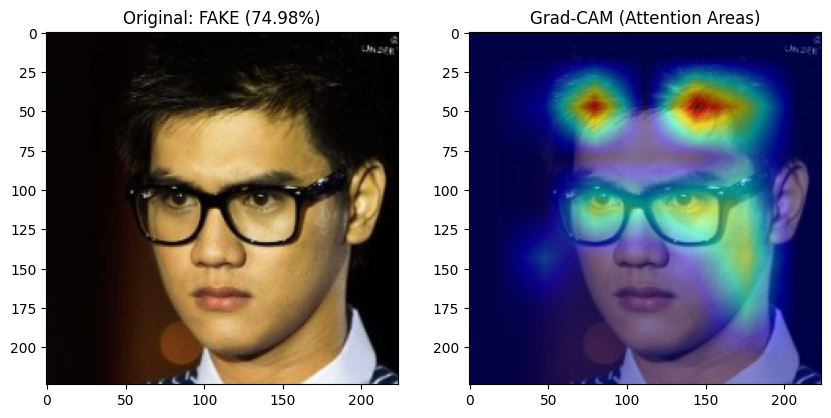

In [12]:
# 1. Initialize the architecture
swin_model = timm.create_model("swin_tiny_patch4_window7_224", num_classes=2)

# 2. Load your weights into the architecture
# USE THE PATH TO YOUR .PTH FILE HERE
WEIGHTS_PATH = "/kaggle/working/DrishtiAI_Final.pth"
swin_model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))

# 3. Handle DataParallel if you are on 2 GPUs
target_model = swin_model.module if isinstance(swin_model, torch.nn.DataParallel) else swin_model
target_model.to(DEVICE)

predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/testing/real.jpeg")
predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/testing/test.jpeg")
predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/testing/me.jpg")
predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/testing/me1.jpg")
predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/testing/fake.webp")

predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/deepfake/f.jpg")
predict_with_gradcam(target_model, "/kaggle/input/datasets/sakshyamkarki04/deepfake/r.jpg")
